In [464]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [465]:
df=pd.read_csv("Algerian_forest_fires_dataset.csv")
df.info()
df.isnull().sum()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
5,6,6,2012,31,67,14,0,82.6,5.8,22.2,3.1,7,2.5,fire
6,7,6,2012,33,54,13,0,88.2,9.9,30.5,6.4,10.9,7.2,fire
7,8,6,2012,30,73,15,0,86.6,12.1,38.3,5.6,13.5,7.1,fire
8,9,6,2012,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,not fire
9,10,6,2012,28,79,12,0,73.2,9.5,46.3,1.3,12.6,0.9,not fire


In [466]:
df[df.isnull().any(axis=1)] #just shows us the rows with null values

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [467]:
df.drop(122, inplace=True)
#Dataset has 2 different locations, line 122 is the key to the second location, so thats why we can drop it without losing any data
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [468]:
df.loc[:123,"Region"]= 0
df.loc[123:,"Region"]= 1
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1.0
243,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1.0
244,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1.0
245,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1.0


In [469]:
df=df.dropna().reset_index(drop=True)
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [470]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [471]:
df.columns=df.columns.str.strip() #removing the spaces from the column names, otherwise it will cause problems when we want to use them in our code
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [472]:
df["day"].unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', '31', 'day'],
      dtype=object)

In [473]:
df.drop(122, inplace=True)
df.iloc[122] #we can drop the row with null values since there is only one row with null values

day                      1
month                    6
year                  2012
Temperature             32
RH                      71
Ws                      12
Rain                   0.7
FFMC                  57.1
DMC                    2.5
DC                     8.2
ISI                    0.6
BUI                    2.8
FWI                    0.2
Classes        not fire   
Region                 1.0
Name: 123, dtype: object

In [474]:
df[["day", "month","year", "Temperature", "RH", "Ws"]] = df[["day", "month","year", "Temperature", "RH", "Ws"]].astype(int)
df[["Rain", "FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]] = df[["Rain", "FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
dtypes: float64(8), int64(6), object(1)
memory usage: 30.4+ KB


In [475]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [476]:
#df["Classes"].unique()
df["Classes"].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [477]:
#df["Classes"]=df["Classes"].str.strip() 
#df["Classes"].unique()
df["Classes"]=np.where(df["Classes"].str.contains('not fire'),0,1)
df["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [478]:
df.corr()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
day,1.000000,-0.000369,NaN,0.097227,-0.076034,0.047812,-0.112523,0.224956,0.491514,0.527952,0.180543,0.517117,0.350781,0.202840,0.000821
month,-0.000369,1.000000,NaN,-0.056781,-0.041252,-0.039880,0.034822,0.017030,0.067943,0.126511,0.065608,0.085073,0.082639,0.024004,0.001857
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,0.097227,-0.056781,NaN,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.076034,-0.041252,NaN,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,0.047812,-0.039880,NaN,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.112523,0.034822,NaN,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.224956,0.017030,NaN,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.491514,0.067943,NaN,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.527952,0.126511,NaN,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734


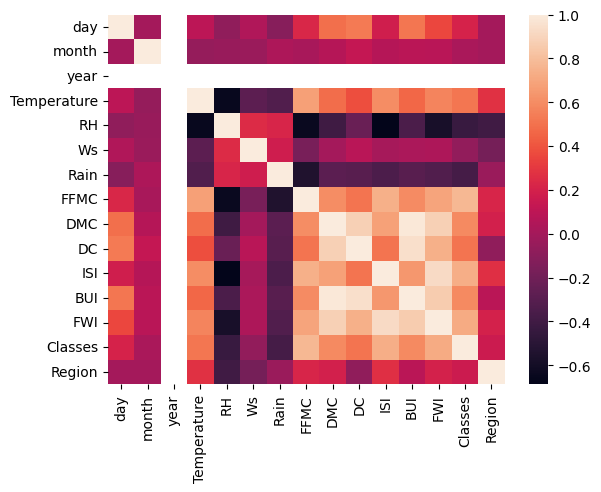

In [479]:
sns.heatmap(df.corr())
plt.show()

In [480]:
df.drop(["day", "month", "year"], axis=1, inplace=True)
df.head(15)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0
5,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,1,0.0
6,33,54,13,0.0,88.2,9.9,30.5,6.4,10.9,7.2,1,0.0
7,30,73,15,0.0,86.6,12.1,38.3,5.6,13.5,7.1,1,0.0
8,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,0,0.0
9,28,79,12,0.0,73.2,9.5,46.3,1.3,12.6,0.9,0,0.0


In [481]:
#dependent and independent features
X=df.drop("FWI", axis=1)
y=df["FWI"]

In [482]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=34)   

In [483]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.659250,-0.277898,-0.253653,0.662887,0.445664,0.350883,0.608642,0.423989,0.494143,0.276826
RH,-0.659250,1.000000,0.257618,0.140447,-0.637819,-0.392125,-0.215959,-0.647173,-0.337315,-0.411941,-0.397003
Ws,-0.277898,0.257618,1.000000,0.084978,-0.162646,0.020198,0.090887,0.027110,0.050190,-0.051643,-0.193785
Rain,-0.253653,0.140447,0.084978,1.000000,-0.495659,-0.301007,-0.305693,-0.366475,-0.312026,-0.390864,0.076540
FFMC,0.662887,-0.637819,-0.162646,-0.495659,1.000000,0.598802,0.501779,0.746367,0.586849,0.769279,0.202539
DMC,0.445664,-0.392125,0.020198,-0.301007,0.598802,1.000000,0.885590,0.680045,0.982530,0.580396,0.169763
DC,0.350883,-0.215959,0.090887,-0.305693,0.501779,0.885590,1.000000,0.510338,0.946470,0.504436,-0.097324
ISI,0.608642,-0.647173,0.027110,-0.366475,0.746367,0.680045,0.510338,1.000000,0.645212,0.750239,0.239321
BUI,0.423989,-0.337315,0.050190,-0.312026,0.586849,0.982530,0.946470,0.645212,1.000000,0.582032,0.063601
Classes,0.494143,-0.411941,-0.051643,-0.390864,0.769279,0.580396,0.504436,0.750239,0.582032,1.000000,0.147434


In [484]:
#redundancy, multicollinearity
def correlation_for_dropping(df,threshold):
    columns_to_drop=set()
    corr=df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j]) > threshold:
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop
#We can see that there are some features that are highly correlated with each other, so we can drop one of them to avoid multicollinearity

In [485]:
columns_dropping=correlation_for_dropping(X_train, 0.85)
columns_dropping

{'BUI', 'DC'}

In [486]:
X_train.drop(columns_dropping, axis=1, inplace=True)
X_test.drop(columns_dropping, axis=1, inplace=True)

In [487]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [488]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

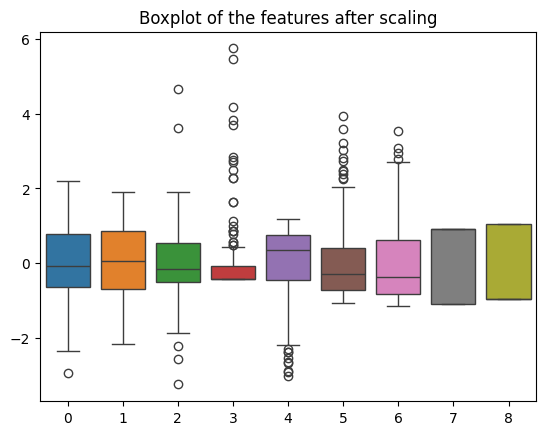

In [489]:
sns.boxplot(data=X_train_scaled)
plt.title("Boxplot of the features after scaling")
plt.show()

Mean Absolute Error: 0.7433926086770394
Mean Squared Error: 1.1040247138789887
R2 Score: 0.9792741570653651


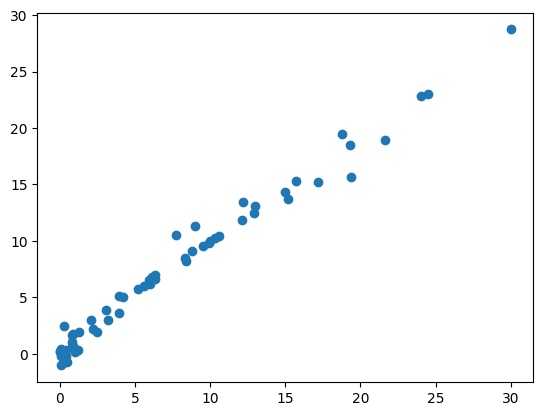

In [490]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
linear=LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred=linear.predict(X_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error: 0.797962464532701
Mean Squared Error: 1.210490310963125
R2 Score: 0.9772754796667813


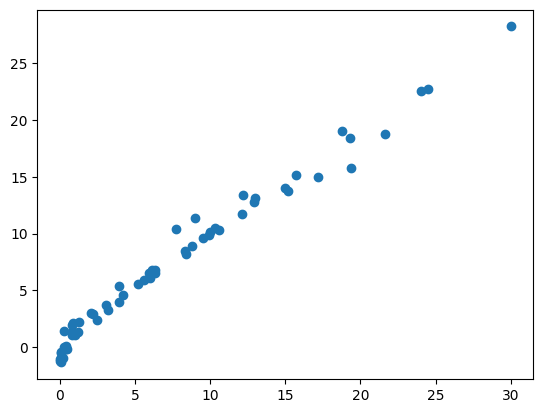

In [491]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
lasso=Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error: 0.7555624552476636
Mean Squared Error: 1.1463864998038178
R2 Score: 0.9784788997577422


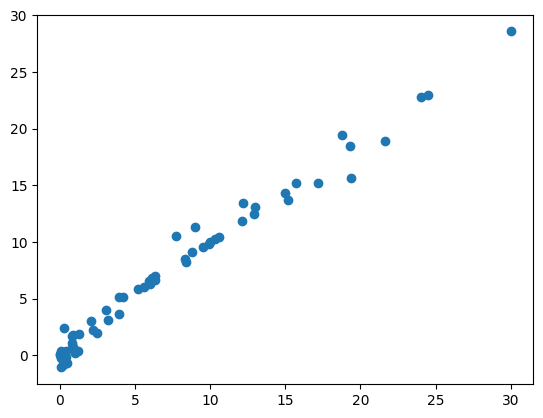

In [492]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
ridge=Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error: 0.9537134683084679
Mean Squared Error: 1.6232020288827202
R2 Score: 0.9695276474531064


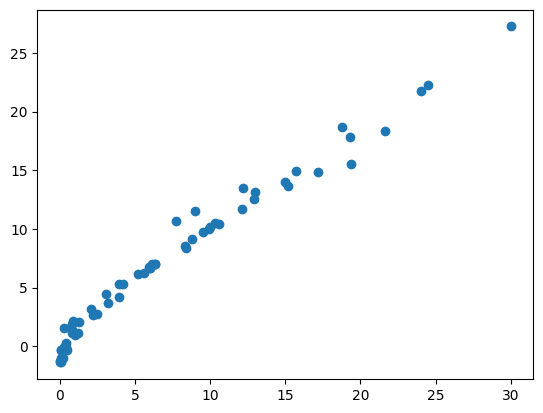

In [493]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
elasticnet=ElasticNet(alpha=0.1, l1_ratio=0.5)
elasticnet.fit(X_train_scaled, y_train)
y_pred=elasticnet.predict(X_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error: 0.7153283722149201
Mean Squared Error: 1.0740971809226747
R2 Score: 0.9798359862886389


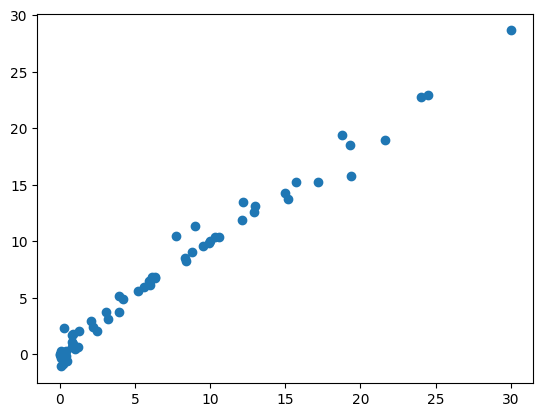

In [500]:
#lasso cross validation
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled, y_train)
y_pred=lassocv.predict(X_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error: 0.7555624552476636
Mean Squared Error: 1.1463864998038178
R2 Score: 0.9784788997577422


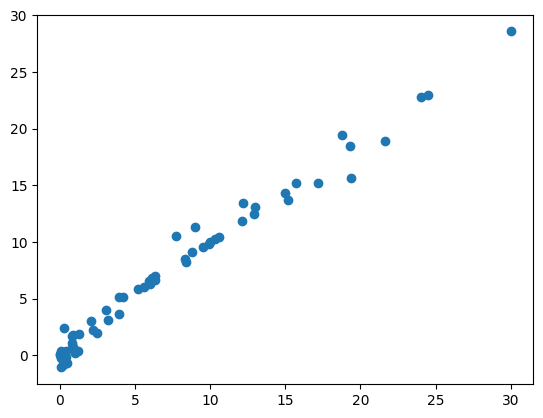

In [501]:
#ridge cross validation
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled, y_train)
y_pred=ridgecv.predict(X_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error: 0.7769433211627259
Mean Squared Error: 1.2099228810352398
R2 Score: 0.9772861320221261


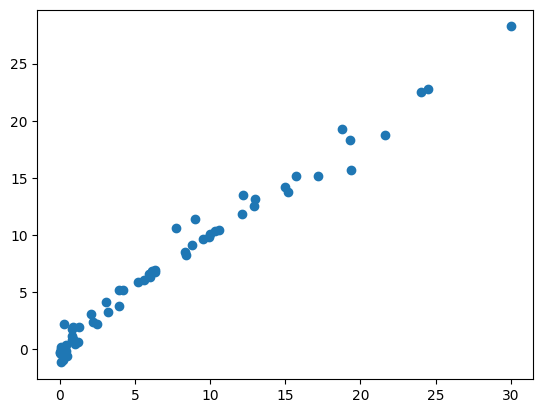

In [502]:
#elasticnet cross validation
from sklearn.linear_model import ElasticNetCV
elasticnetcv=ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_scaled, y_train)
y_pred=elasticnetcv.predict(X_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.show()

In [ ]:
#lazy predict
!pip install lazypredict
#lazy predict is a library that allows us to quickly compare the performance of different regression models without having to write a lot of code for each model.
#It will automatically fit and evaluate multiple regression models and provide us with a summary of their performance metrics.


   -------------------- ------------------- 1/2 [lazypredict]
   ---------------------------------------- 2/2 [lazypredict]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [506]:
from lazypredict.Supervised import LazyRegressor
X_trainlazy, y_trainlazy = X_train_scaled, y_train
X_testlazy, y_testlazy = X_test_scaled, y_test
lazyfit=LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = lazyfit.fit(X_trainlazy, X_testlazy, y_trainlazy, y_testlazy)
print(models)

                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
LinearSVR                                0.984504   0.986828  0.837634   
HuberRegressor                           0.983494   0.985970  0.864501   
ExtraTreesRegressor                      0.978780   0.981963  0.980208   
RANSACRegressor                          0.977995   0.981295  0.998178   
OrthogonalMatchingPursuitCV              0.977993   0.981294  0.998221   
LassoCV                                  0.976278   0.979836  1.036387   
LassoLarsCV                              0.975617   0.979274  1.050726   
LassoLarsIC                              0.975617   0.979274  1.050726   
LarsCV                                   0.975617   0.979274  1.050726   
Lars                                     0.975617   0.979274  1.050726   
TransformedTargetRegressor               0.975617   0.979274  1.050726   
LinearRegression                      